In [8]:
import numpy as np
import scipy
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sp




In [13]:
import sys
!{sys.executable} -m pip install sympy

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 46.9 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 17.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   --------------------

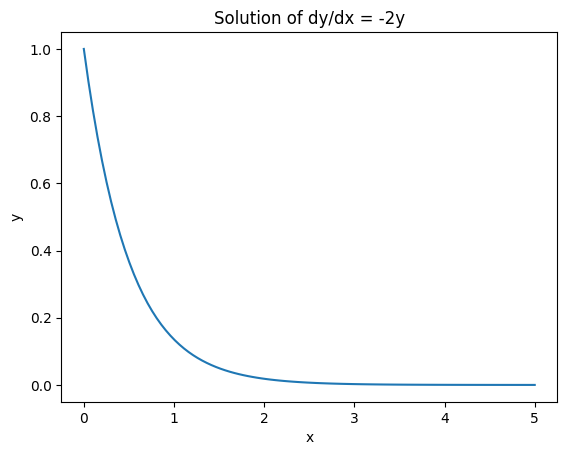

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE: dy/dx = -2y
def f(x, y):
    return -2*y

# Interval
x_span = (0, 5)

# Initial condition
y0 = [1]

# Solve
sol = solve_ivp(f, x_span, y0, t_eval=np.linspace(0, 5, 100))

# Plot
plt.plot(sol.t, sol.y[0])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solution of dy/dx = -2y")
plt.show()

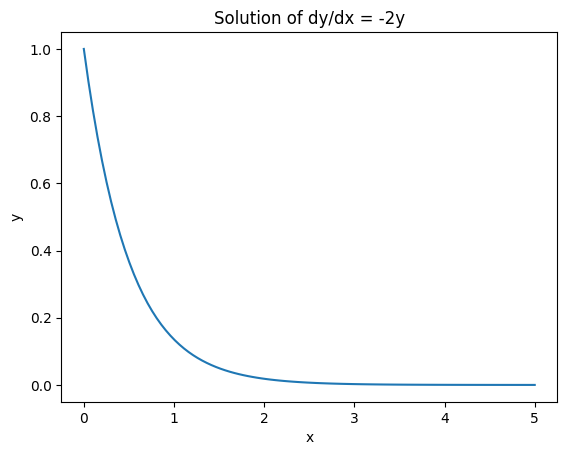

In [3]:
# Define the ODE: dy/dx = -2y
def f(x, y):
    return -2*y

# Interval
x_span = (0, 5)

# Initial condition
y0 = [1]

# Solve
sol = solve_ivp(f, x_span, y0, t_eval=np.linspace(0, 5, 100))

# Plot
plt.plot(sol.t, sol.y[0])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solution of dy/dx = -2y")
plt.show()

In [6]:
f(-2,-3)

6

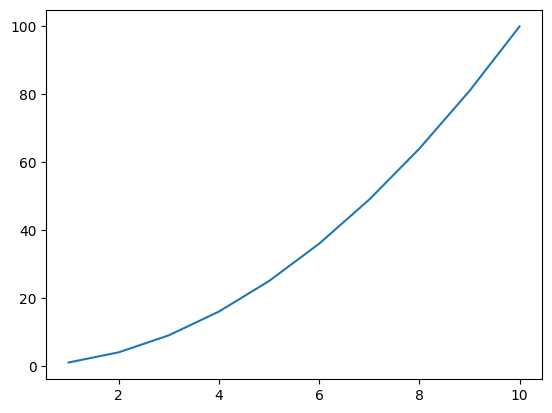

In [9]:
data = np.loadtxt("dataset.txt")

x = data[:,0]
y = data[:,1]

plt.plot(x,y)
plt.show()

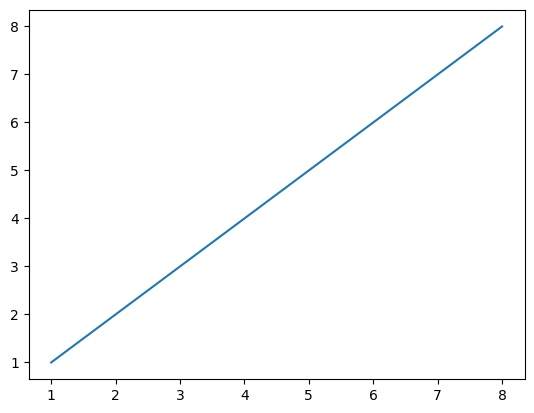

In [16]:
x1 = np.array([1,2,3,4,5,6,7,8])
x2 = np.array([1,2,3,4,5,6,7,8])

plt.plot(x1,x2)
plt.show()

In [17]:
correlation = np.corrcoef(x1,x2)

print(correlation)

[[1. 1.]
 [1. 1.]]


In [2]:
#Monte Carlo Field Theory

N = 100
phi = np.random.randn(N)
m = 1.0
g=1.0
h=1.0

def action(phi):
    grad = np.roll(phi, -1) - phi
    return np.sum(grad**2 + m**2 * phi**2)

In [3]:
def metropolis(phi, beta=1.0):
    for _ in range(N):
        i = np.random.randint(0, N)
        old = phi[i]
        
        phi[i] += np.random.randn() * 0.5
        
        dS = action(phi) - action(np.copy(phi).astype(float))
        
        if np.random.rand() > np.exp(-beta * dS):
            phi[i] = old
            
    return phi

In [4]:
samples = []

for _ in range(1000):
    phi = metropolis(phi)
    samples.append(phi.copy())

samples = np.array(samples)

In [56]:
def correlation(phi):
    phi = phi - np.mean(phi)
    return np.correlate(phi, phi, mode='full') / len(phi)

corr = np.mean([correlation(s) for s in samples], axis=0)

In [57]:
print(corr)

[-1.18301583e+00  4.84474737e+00  2.55758537e+00 -7.71937471e+00
 -4.01863866e+00  3.43564628e+00  7.46442868e+00 -2.32481302e+00
  6.53009474e-03  5.90092615e+00  2.04722520e+00 -8.16630596e-01
 -7.71421435e+00  6.29642882e+00  5.72002137e+00 -8.77293124e-01
 -1.48299715e-01  3.50008737e+00  1.18414466e+01 -8.40534429e-01
 -3.96246984e+00  2.35030223e+00 -1.32343693e+00  1.13700290e+01
  1.98635983e+00 -4.72174617e+00 -1.91524298e+00  7.95270117e+00
 -8.19618464e+00 -2.95796229e+00 -9.18365339e+00  1.77023291e+00
 -7.78601441e-01 -1.02783166e+00  6.96625210e+00 -3.17552132e+00
 -3.30521959e+00 -8.31786790e+00 -4.06235216e+00  2.47632178e+00
 -1.37387740e+01 -5.81788731e+00  1.85815449e+00  1.12148144e+00
 -8.79741599e+00  9.26278094e-01  9.36145469e+00 -1.36135316e+01
  9.67304166e+00  1.26169685e+00  1.05655157e+01 -2.74253133e+00
 -1.21626091e+01 -1.79868440e+01  1.20682109e+01 -1.46929927e+00
 -6.48420634e+00 -8.49621062e+00  7.26404275e+00  6.90172651e+00
 -1.36215860e+01 -8.67549

In [58]:
my_corr = np.array(corr)
numbers = np.arange(1,200)

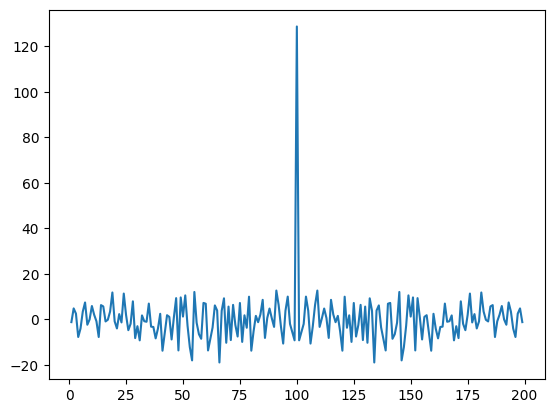

In [59]:
plt.plot(numbers,my_corr)
plt.show()

In [61]:
def correlation0(phi):
    phi = phi - np.mean(phi)
    return np.correlate(phi, phi, phi, mode='full') / len(phi)

corr0 = np.mean([correlation(s) for s in samples], axis=0)

In [62]:
print(corr0)

[-1.18301583e+00  4.84474737e+00  2.55758537e+00 -7.71937471e+00
 -4.01863866e+00  3.43564628e+00  7.46442868e+00 -2.32481302e+00
  6.53009474e-03  5.90092615e+00  2.04722520e+00 -8.16630596e-01
 -7.71421435e+00  6.29642882e+00  5.72002137e+00 -8.77293124e-01
 -1.48299715e-01  3.50008737e+00  1.18414466e+01 -8.40534429e-01
 -3.96246984e+00  2.35030223e+00 -1.32343693e+00  1.13700290e+01
  1.98635983e+00 -4.72174617e+00 -1.91524298e+00  7.95270117e+00
 -8.19618464e+00 -2.95796229e+00 -9.18365339e+00  1.77023291e+00
 -7.78601441e-01 -1.02783166e+00  6.96625210e+00 -3.17552132e+00
 -3.30521959e+00 -8.31786790e+00 -4.06235216e+00  2.47632178e+00
 -1.37387740e+01 -5.81788731e+00  1.85815449e+00  1.12148144e+00
 -8.79741599e+00  9.26278094e-01  9.36145469e+00 -1.36135316e+01
  9.67304166e+00  1.26169685e+00  1.05655157e+01 -2.74253133e+00
 -1.21626091e+01 -1.79868440e+01  1.20682109e+01 -1.46929927e+00
 -6.48420634e+00 -8.49621062e+00  7.26404275e+00  6.90172651e+00
 -1.36215860e+01 -8.67549

In [63]:
mycorr0 = np.array(corr0)
xcoord = np.arange(1,200)

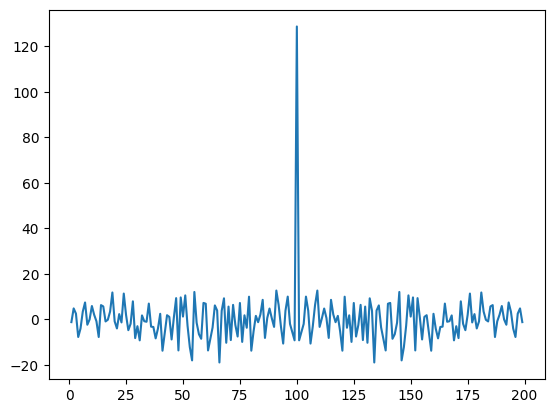

In [64]:
plt.plot(xcoord,mycorr0)
plt.show()

In [7]:
mylist = [0,1,2,3,4,5,9]
np.array(mylist)

array([0, 1, 2, 3, 4, 5, 9])

In [11]:
data = np.loadtxt("dataset.txt")

In [24]:
x = data[:,0]
y = data[:,1]
z = data[:,2]
z[8]

np.float64(10.0)

In [29]:
x1 = np.array(x)
x2 = np.array(y)
x3 = np.array(z)

In [32]:
np.corrcoef([x1,x2,x3])

array([[1.        , 0.97455863, 1.        ],
       [0.97455863, 1.        , 0.97455863],
       [1.        , 0.97455863, 1.        ]])